# Exploratory analysis comparing 2024 marathon prep to 2025 marathon prep
## Identify / Compare:
[]average pace
[]weekly average mileage
[]monthly average mileage from july to October
[]anything interesting about heart rate data

## Potential Questions
1. which training period had more prep
2. training plan didn't change a whole lot - why were times so different
3. try to incorporate some sort of average heartrate analysis
4. maybe incorporate some sort of regression analysis

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

activities = pd.read_csv('../data/activities.csv')
activities.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,Activity Private Note,Activity Gear,Filename,Athlete Weight,Bike Weight,Elapsed Time.1,Moving Time,Distance.1,Max Speed,Average Speed,Elevation Gain,Elevation Loss,Elevation Low,Elevation High,Max Grade,Average Grade,Average Positive Grade,Average Negative Grade,Max Cadence,Average Cadence,Max Heart Rate.1,Average Heart Rate,Max Watts,Average Watts,Calories,Max Temperature,Average Temperature,Relative Effort.1,Total Work,Number of Runs,Uphill Time,Downhill Time,Other Time,Perceived Exertion,Type,Start Time,Weighted Average Power,Power Count,Prefer Perceived Exertion,Perceived Relative Effort,Commute.1,Total Weight Lifted,From Upload,Grade Adjusted Distance,Weather Observation Time,Weather Condition,Weather Temperature,Apparent Temperature,Dewpoint,Humidity,Weather Pressure,Wind Speed,Wind Gust,Wind Bearing,Precipitation Intensity,Sunrise Time,Sunset Time,Moon Phase,Bike,Gear,Precipitation Probability,Precipitation Type,Cloud Cover,Weather Visibility,UV Index,Weather Ozone,Jump Count,Total Grit,Average Flow,Flagged,Average Elapsed Speed,Dirt Distance,Newly Explored Distance,Newly Explored Dirt Distance,Activity Count,Total Steps,Carbon Saved,Pool Length,Training Load,Intensity,Average Grade Adjusted Pace,Timer Time,Total Cycles,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media
0,1367203136,"Jan 21, 2018, 1:26:02 AM",Evening Run,Run,NaN,769,2.74,209.0,45.0,False,NaN,NaN,activities/1476482114.tcx.gz,70.8,NaN,769.0,735.0,2745.7,4.1,NaN,20.0,NaN,217.1,228.0,7.0,0.0,NaN,NaN,NaN,NaN,209.0,180.0,NaN,NaN,NaN,NaN,NaN,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1367203273,"Jan 19, 2018, 10:55:21 PM",Afternoon Run,Run,NaN,6569,10.37,171.0,30.0,False,NaN,NaN,activities/1476482189.tcx.gz,70.8,NaN,6569.0,6528.0,10373.5,3.8,NaN,0.0,NaN,205.8,207.4,4.0,0.0,NaN,NaN,NaN,NaN,171.0,115.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1371326189,"Jan 23, 2018, 12:10:09 PM",Morning Run,Run,NaN,2867,7.36,192.0,36.0,False,NaN,NaN,activities/1480762072.tcx.gz,70.8,NaN,2867.0,2343.0,7365.0,4.8,NaN,0.0,NaN,205.8,207.4,2.5,0.0,NaN,NaN,NaN,NaN,192.0,143.0,NaN,NaN,NaN,NaN,NaN,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1372867134,"Jan 24, 2018, 11:30:54 AM",Morning Run,Run,NaN,4738,8.19,175.0,25.0,False,NaN,NaN,activities/1482339097.tcx.gz,70.8,NaN,4738.0,4628.0,8196.4,3.9,NaN,0.0,NaN,205.8,207.3,3.8,0.0,NaN,NaN,NaN,NaN,175.0,123.0,NaN,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1375484414,"Jan 26, 2018, 12:52:39 AM",Evening Run,Run,NaN,1011,3.27,176.0,31.0,False,NaN,NaN,activities/1484994119.tcx.gz,70.8,NaN,1011.0,899.0,3272.1,4.2,NaN,21.9,NaN,216.9,228.1,8.8,0.0,NaN,NaN,NaN,NaN,176.0,158.0,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [2]:
# Try to get a feel for the df
activities.info()

<class 'pandas.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Columns: 103 entries, Activity ID to Media
dtypes: bool(1), float64(93), int64(2), str(7)
memory usage: 510.0 KB


In [8]:
# Yikes - 103 columns is a lot
list(activities.columns)
for column in activities.columns:
    print(column)

Activity ID
Activity Date
Activity Name
Activity Type
Activity Description
Elapsed Time
Distance
Max Heart Rate
Relative Effort
Commute
Activity Private Note
Activity Gear
Filename
Athlete Weight
Bike Weight
Elapsed Time.1
Moving Time
Distance.1
Max Speed
Average Speed
Elevation Gain
Elevation Loss
Elevation Low
Elevation High
Max Grade
Average Grade
Average Positive Grade
Average Negative Grade
Max Cadence
Average Cadence
Max Heart Rate.1
Average Heart Rate
Max Watts
Average Watts
Calories
Max Temperature
Average Temperature
Relative Effort.1
Total Work
Number of Runs
Uphill Time
Downhill Time
Other Time
Perceived Exertion
Type
Start Time
Weighted Average Power
Power Count
Prefer Perceived Exertion
Perceived Relative Effort
Commute.1
Total Weight Lifted
From Upload
Grade Adjusted Distance
Weather Observation Time
Weather Condition
Weather Temperature
Apparent Temperature
Dewpoint
Humidity
Weather Pressure
Wind Speed
Wind Gust
Wind Bearing
Precipitation Intensity
Sunrise Time
Sunset Ti

In [ ]:
# Lets filter to only Run activity types
isRun = activities['Activity Type'] == 'Run' & 
activities = activities[isRun]
activities.info()

<class 'pandas.DataFrame'>
Index: 592 entries, 0 to 638
Columns: 103 entries, Activity ID to Media
dtypes: bool(1), float64(93), int64(2), str(7)
memory usage: 477.0 KB


In [ ]:
# Now let's trim down to only relevant columns
activities = activities[['Activity Type', 'Distance', 'Moving Time', 'Average Heart Rate', 'Activity Date', 'Elevation Gain', 'Activity Description']]
activities.head()

,Activity Type,Distance,Moving Time,Average Heart Rate,Activity Date,Elevation Gain,Activity Description
0,Run,2.74,735.0,180.0,"Jan 21, 2018, 1:26:02 AM",20.0,NaN
1,Run,10.37,6528.0,115.0,"Jan 19, 2018, 10:55:21 PM",0.0,NaN
2,Run,7.36,2343.0,143.0,"Jan 23, 2018, 12:10:09 PM",0.0,NaN
3,Run,8.19,4628.0,123.0,"Jan 24, 2018, 11:30:54 AM",0.0,NaN
4,Run,3.27,899.0,158.0,"Jan 26, 2018, 12:52:39 AM",21.9,NaN


In [ ]:
# Let's check data types before calculations
activities.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, 0 to 638
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Activity Type         592 non-null    object 
 1   Distance              592 non-null    float64
 2   Moving Time           592 non-null    float64
 3   Average Heart Rate    555 non-null    float64
 4   Activity Date         592 non-null    object 
 5   Elevation Gain        588 non-null    float64
 6   Activity Description  202 non-null    object 
dtypes: float64(4), object(3)
memory usage: 37.0+ KB


In [ ]:
# Yikes - need to convert Activity Date to a date datatype
activities['Activity Date'] = pd.to_datetime(activities['Activity Date'])
activities.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, 0 to 638
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity Type         592 non-null    object        
 1   Distance              592 non-null    float64       
 2   Moving Time           592 non-null    float64       
 3   Average Heart Rate    555 non-null    float64       
 4   Activity Date         592 non-null    datetime64[ns]
 5   Elevation Gain        588 non-null    float64       
 6   Activity Description  202 non-null    object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 37.0+ KB


In [ ]:
activities.head()

,Activity Type,Distance,Moving Time,Average Heart Rate,Activity Date,Elevation Gain,Activity Description
0,Run,2.74,735.0,180.0,2018-01-21 01:26:02,20.0,NaN
1,Run,10.37,6528.0,115.0,2018-01-19 22:55:21,0.0,NaN
2,Run,7.36,2343.0,143.0,2018-01-23 12:10:09,0.0,NaN
3,Run,8.19,4628.0,123.0,2018-01-24 11:30:54,0.0,NaN
4,Run,3.27,899.0,158.0,2018-01-26 00:52:39,21.9,NaN


In [ ]:
# Okay we're getting there - need to convert moving time from seconds to minutes & generate pace per mile
activities['Moving Time'] = activities['Moving Time'] / 60
activities.sort_values(by='Distance')

,Activity Type,Distance,Moving Time,Average Heart Rate,Activity Date,Elevation Gain,Activity Description
410,Run,0.00,105.000000,NaN,2023-07-27 11:00:30,NaN,Deadlift: 260 (leave me alone)\nBall throw: 10...
33,Run,0.23,1.150000,NaN,2018-06-06 15:10:25,0.0,NaN
18,Run,0.33,1.266667,NaN,2018-05-02 23:55:27,0.0,NaN
161,Run,0.39,1.366667,148.0,2021-05-04 16:49:53,1.0,2/5
164,Run,0.39,1.366667,145.0,2021-05-04 17:02:11,1.0,5/5
...,...,...,...,...,...,...,...
14,Run,42.05,414.000000,140.0,2018-03-25 13:45:46,636.3,NaN
115,Run,42.22,270.016667,150.0,2020-12-05 15:20:08,83.0,hit a phat wall at mile 18 that i couldn’t bre...
519,Run,42.40,233.216667,164.0,2024-10-13 07:45:36,98.0,I’m tired
618,Run,42.87,226.650000,161.0,2025-10-05 08:31:28,201.0,do u even bonk


In [ ]:
# Welp I guess the distance is in kilometers
activities['DistanceInMiles'] = activities['Distance'] * .621371
activities['Pace'] = activities['Moving Time'] / activities['DistanceInMiles']
activities.head()

,Activity Type,Distance,Moving Time,Average Heart Rate,Activity Date,Elevation Gain,Activity Description,DistanceInMiles,Pace
0,Run,2.74,12.250000,180.0,2018-01-21 01:26:02,20.0,NaN,1.702557,7.195062
1,Run,10.37,108.800000,115.0,2018-01-19 22:55:21,0.0,NaN,6.443617,16.884926
2,Run,7.36,39.050000,143.0,2018-01-23 12:10:09,0.0,NaN,4.573291,8.538710
3,Run,8.19,77.133333,123.0,2018-01-24 11:30:54,0.0,NaN,5.089028,15.156789
4,Run,3.27,14.983333,158.0,2018-01-26 00:52:39,21.9,NaN,2.031883,7.374112


In [ ]:
# Make Activity Date more usable / break out by year / month / week
activities['Activity Year'] = activities['Activity Date'].dt.year
activities['Activity Month'] = activities['Activity Date'].dt.month
activities['Activity Week'] = activities['Activity Date'].dt.to_period('W')
activities.head()

,Activity Type,Distance,Moving Time,Average Heart Rate,Activity Date,Elevation Gain,Activity Description,DistanceInMiles,Pace,Activity Year,Activity Month,Activity Week
0,Run,2.74,12.250000,180.0,2018-01-21 01:26:02,20.0,NaN,1.702557,7.195062,2018,1,2018-01-15/2018-01-21
1,Run,10.37,108.800000,115.0,2018-01-19 22:55:21,0.0,NaN,6.443617,16.884926,2018,1,2018-01-15/2018-01-21
2,Run,7.36,39.050000,143.0,2018-01-23 12:10:09,0.0,NaN,4.573291,8.538710,2018,1,2018-01-22/2018-01-28
3,Run,8.19,77.133333,123.0,2018-01-24 11:30:54,0.0,NaN,5.089028,15.156789,2018,1,2018-01-22/2018-01-28
4,Run,3.27,14.983333,158.0,2018-01-26 00:52:39,21.9,NaN,2.031883,7.374112,2018,1,2018-01-22/2018-01-28


In [ ]:
# Should be able to create weekly df - might revisit Activity week later
weekly = activities.groupby(['Activity Year', 'Activity Week']).agg({
    'DistanceInMiles': 'sum',
    'Pace': 'mean',
    'Average Heart Rate': 'mean'
}).reset_index()
weekly.head(10)

,Activity Year,Activity Week,DistanceInMiles,Pace,Average Heart Rate
0,2018,2018-01-15/2018-01-21,8.146174,12.039994,147.5
1,2018,2018-01-22/2018-01-28,19.753384,11.123306,140.5
2,2018,2018-01-29/2018-02-04,2.013242,7.583125,163.0
3,2018,2018-02-12/2018-02-18,14.577364,12.734878,139.0
4,2018,2018-02-26/2018-03-04,5.499133,8.774110,159.0
5,2018,2018-03-05/2018-03-11,6.014871,7.567914,164.0
6,2018,2018-03-12/2018-03-18,2.516553,7.881152,158.0
7,2018,2018-03-19/2018-03-25,26.128651,15.844676,140.0
8,2018,2018-03-26/2018-04-01,5.430783,7.569738,164.0
9,2018,2018-04-02/2018-04-08,12.166444,12.457762,136.0


In [ ]:
is2024 = weekly['Activity Year'] == 2024
is2025 = weekly['Activity Year'] == 2025
weekly24 = weekly[is2024]
weekly25 = weekly[is2025]
weekly24.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 149 to 193
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   Activity Year       45 non-null     int32        
 1   Activity Week       45 non-null     period[W-SUN]
 2   DistanceInMiles     45 non-null     float64      
 3   Pace                45 non-null     float64      
 4   Average Heart Rate  45 non-null     float64      
dtypes: float64(3), int32(1), period[W-SUN](1)
memory usage: 1.9 KB


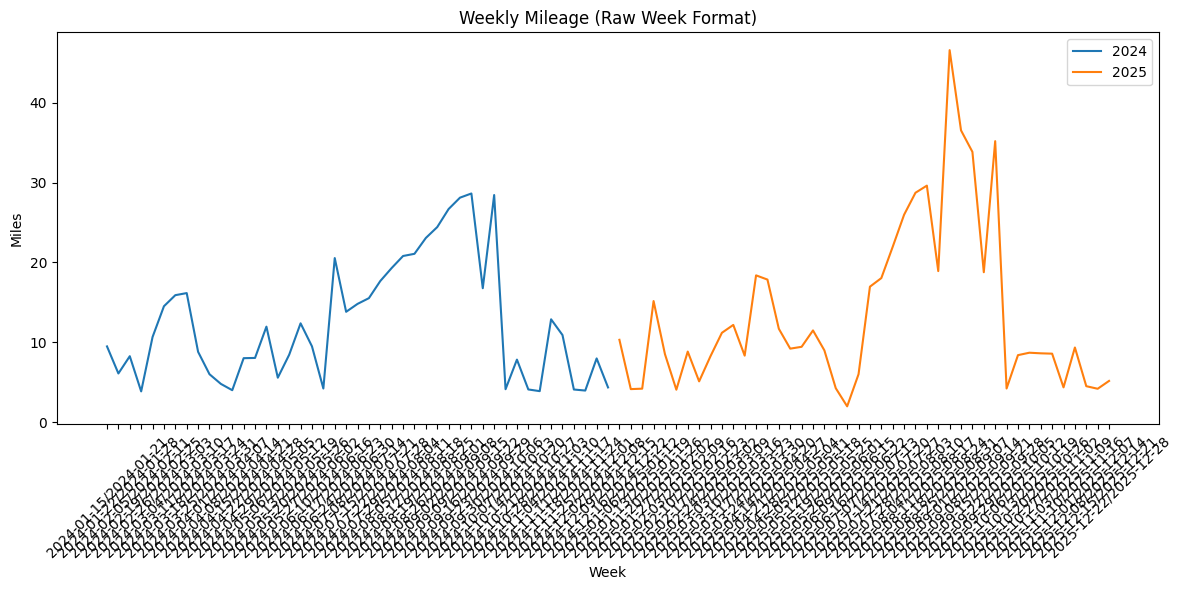

In [ ]:
# Let's Plot weekly data from 2024 and 2025
plt.figure(figsize=(12, 6))

plt.plot(weekly24['Activity Week'].astype(str), weekly24['DistanceInMiles'], label='2024')
plt.plot(weekly25['Activity Week'].astype(str), weekly25['DistanceInMiles'], label='2025')

plt.title('Weekly Mileage (Raw Week Format)')
plt.xlabel('Week')
plt.ylabel('Miles')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Okay - not a fan of the weekly format
weekly['newWeekStart'] = weekly['Activity Week'].dt.start_time
weekly.head()

,Activity Year,Activity Week,DistanceInMiles,Pace,Average Heart Rate,newWeekStart
0,2018,2018-01-15/2018-01-21,8.146174,12.039994,147.5,2018-01-15
1,2018,2018-01-22/2018-01-28,19.753384,11.123306,140.5,2018-01-22
2,2018,2018-01-29/2018-02-04,2.013242,7.583125,163.0,2018-01-29
3,2018,2018-02-12/2018-02-18,14.577364,12.734878,139.0,2018-02-12
4,2018,2018-02-26/2018-03-04,5.499133,8.774110,159.0,2018-02-26


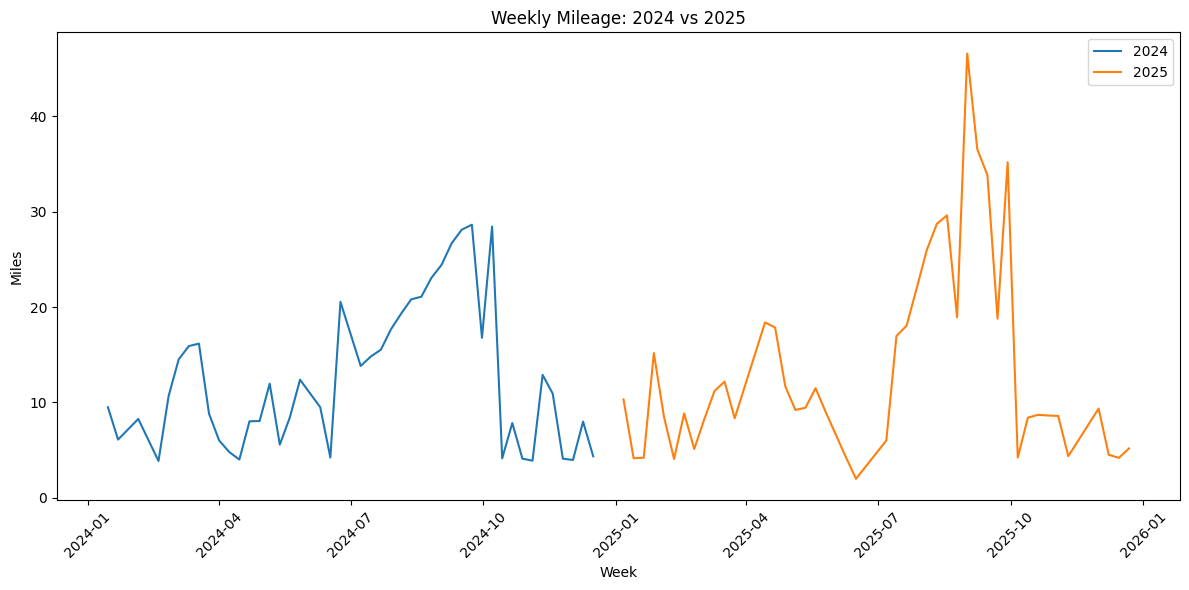

In [ ]:
#Create same chart but use newWeekStart instead of Actiivty Week 
weekly24 = weekly[weekly['Activity Year'] == 2024]
weekly25 = weekly[weekly['Activity Year'] == 2025]

plt.figure(figsize=(12, 6))

plt.plot(weekly24['newWeekStart'], weekly24['DistanceInMiles'], label='2024')
plt.plot(weekly25['newWeekStart'], weekly25['DistanceInMiles'], label='2025')

plt.title('Weekly Mileage: 2024 vs 2025')
plt.xlabel('Week')
plt.ylabel('Miles')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
weekly.head()

,Activity Year,Activity Week,DistanceInMiles,Pace,Average Heart Rate,newWeekStart
0,2018,2018-01-15/2018-01-21,8.146174,12.039994,147.5,2018-01-15
1,2018,2018-01-22/2018-01-28,19.753384,11.123306,140.5,2018-01-22
2,2018,2018-01-29/2018-02-04,2.013242,7.583125,163.0,2018-01-29
3,2018,2018-02-12/2018-02-18,14.577364,12.734878,139.0,2018-02-12
4,2018,2018-02-26/2018-03-04,5.499133,8.774110,159.0,2018-02-26


In [ ]:
# Increment on week_num after sorting each df in chronological order
weekly24 = weekly[weekly['Activity Year'] == 2024].copy()
weekly25 = weekly[weekly['Activity Year'] == 2025].copy()

weekly24 = weekly24.sort_values('newWeekStart')
weekly25 = weekly25.sort_values('newWeekStart')

weekly24['week_num'] = range(1, len(weekly24) + 1)
weekly25['week_num'] = range(1, len(weekly25) + 1)
weekly24.head()

,Activity Year,Activity Week,DistanceInMiles,Pace,Average Heart Rate,newWeekStart,week_num
149,2024,2024-01-15/2024-01-21,9.488335,8.520983,149.0,2024-01-15,1
150,2024,2024-01-22/2024-01-28,6.101863,10.995134,133.0,2024-01-22,2
151,2024,2024-02-05/2024-02-11,8.264234,9.006797,154.0,2024-02-05,3
152,2024,2024-02-19/2024-02-25,3.858714,9.411599,157.0,2024-02-19,4
153,2024,2024-02-26/2024-03-03,10.662726,9.616543,147.5,2024-02-26,5


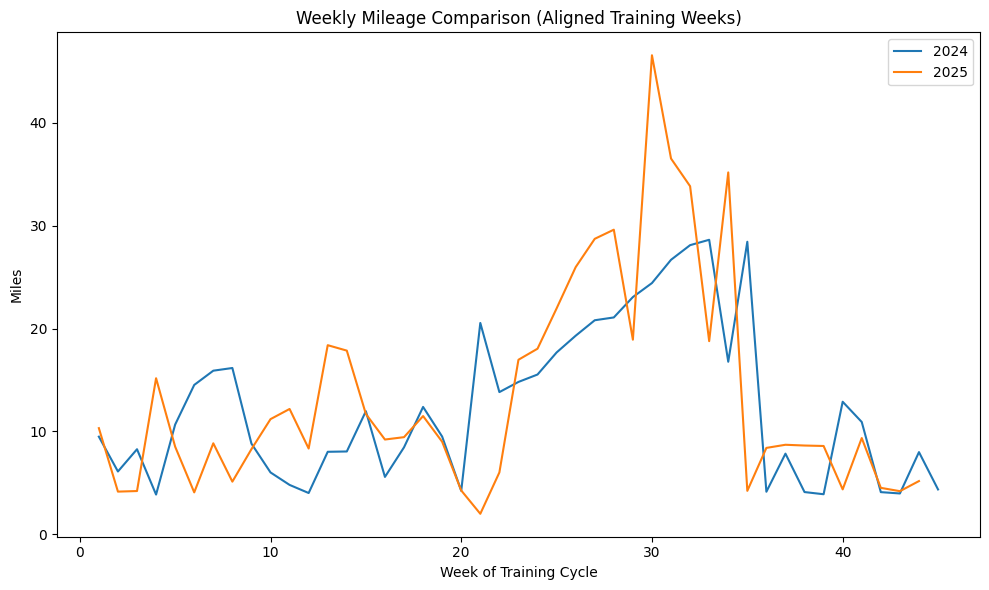

In [ ]:
# Actual plot
plt.figure(figsize=(10, 6))

plt.plot(weekly24['week_num'], weekly24['DistanceInMiles'], label='2024')
plt.plot(weekly25['week_num'], weekly25['DistanceInMiles'], label='2025')

plt.title('Weekly Mileage Comparison (Aligned Training Weeks)')
plt.xlabel('Week of Training Cycle')
plt.ylabel('Miles')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Bring in marathon race dates from each year
race_2024 = pd.to_datetime('2024-10-13') # 3 Countries Marathon
race_2025 = pd.to_datetime('2025-10-05') # Cologne Marathon

In [ ]:
weekly24 = weekly[weekly['Activity Year'] == 2024].copy()
weekly25 = weekly[weekly['Activity Year'] == 2025].copy()

weekly24['weeks_to_race'] = ((weekly24['newWeekStart'] - race_2024).dt.days / 7).astype(int)
weekly25['weeks_to_race'] = ((weekly25['newWeekStart'] - race_2025).dt.days / 7).astype(int)

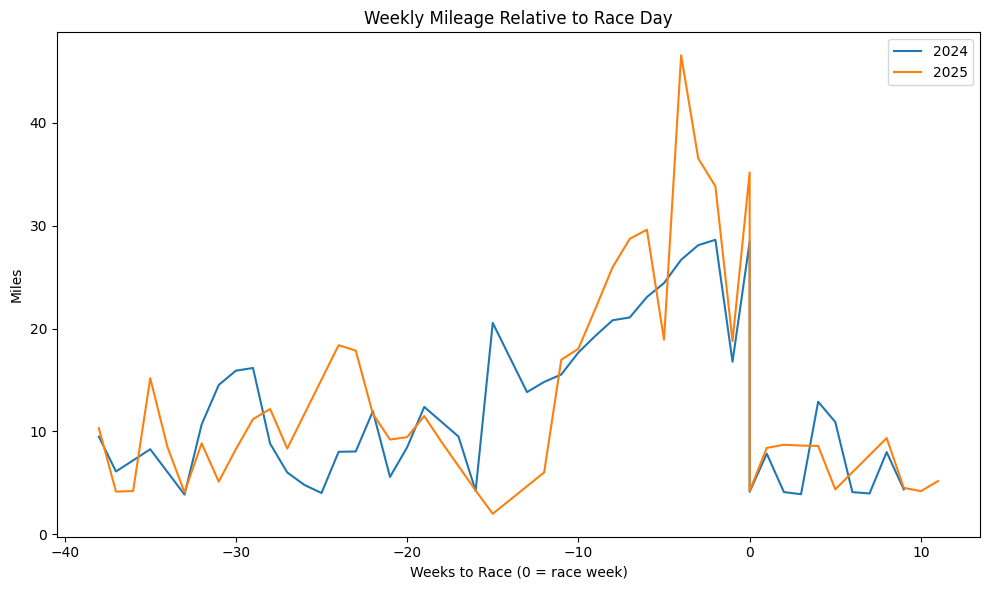

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(weekly24['weeks_to_race'], weekly24['DistanceInMiles'], label='2024')
plt.plot(weekly25['weeks_to_race'], weekly25['DistanceInMiles'], label='2025')

plt.title('Weekly Mileage Relative to Race Day')
plt.xlabel('Weeks to Race (0 = race week)')
plt.ylabel('Miles')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Create Month Labels
weekly24['month'] = weekly24['newWeekStart'].dt.strftime('%b')
weekly25['month'] = weekly25['newWeekStart'].dt.strftime('%b')

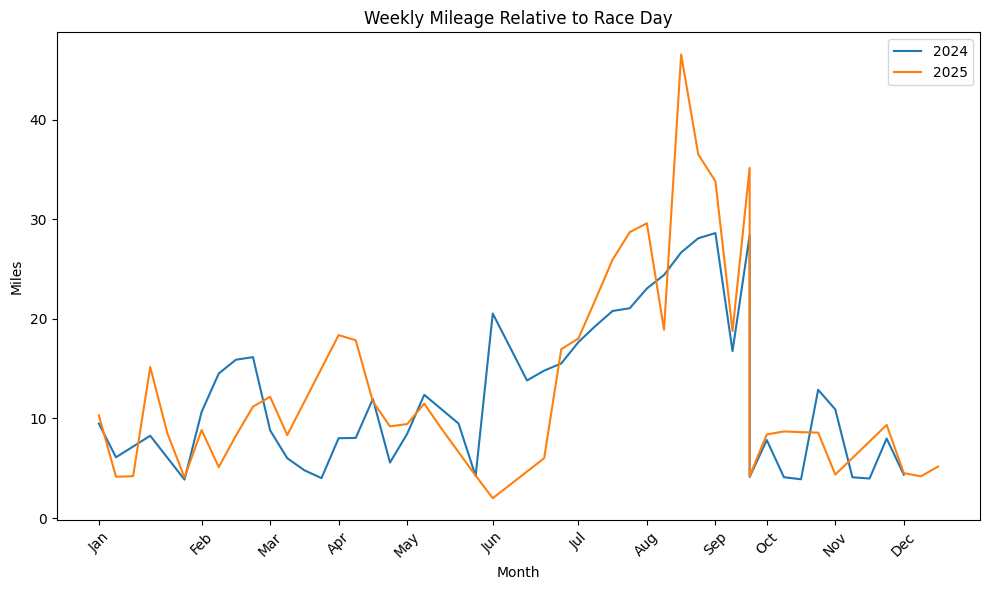

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(weekly24['weeks_to_race'], weekly24['DistanceInMiles'], label='2024')
plt.plot(weekly25['weeks_to_race'], weekly25['DistanceInMiles'], label='2025')

tick_positions = weekly24['weeks_to_race'][::4]
tick_labels = weekly24['newWeekStart'][::4].dt.strftime('%b')

plt.xticks(tick_positions, tick_labels, rotation=45)

plt.title('Weekly Mileage Relative to Race Day')
plt.xlabel('Month')
plt.ylabel('Miles')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
weekly24_trim = weekly24[(weekly24['weeks_to_race'] >= -16) & (weekly24['weeks_to_race'] <= 0)]
weekly25_trim = weekly25[(weekly25['weeks_to_race'] >= -16) & (weekly25['weeks_to_race'] <= 0)]

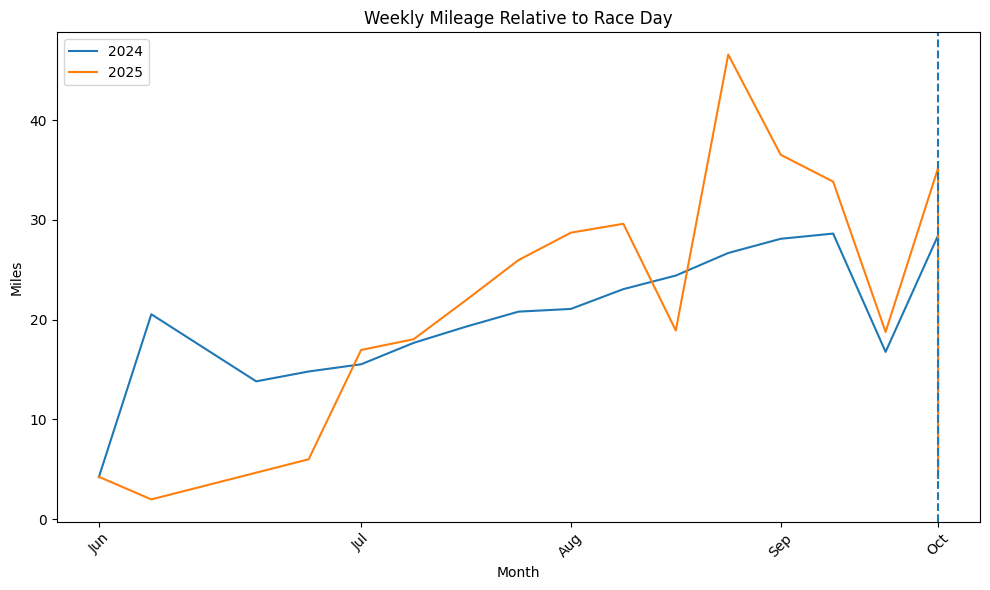

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(weekly24_trim['weeks_to_race'], weekly24_trim['DistanceInMiles'], label='2024')
plt.plot(weekly25_trim['weeks_to_race'], weekly25_trim['DistanceInMiles'], label='2025')

tick_positions = weekly24_trim['weeks_to_race'][::4]
tick_labels = weekly24_trim['newWeekStart'][::4].dt.strftime('%b')
weekly24_trim = weekly24[(weekly24['weeks_to_race'] >= -16) & (weekly24['weeks_to_race'] <= 0)]
weekly25_trim = weekly25[(weekly25['weeks_to_race'] >= -16) & (weekly25['weeks_to_race'] <= 0)]
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.axvline(0, linestyle='--')

plt.title('Weekly Mileage Relative to Race Day')
plt.xlabel('Month')
plt.ylabel('Miles')
plt.legend()
plt.tight_layout()
plt.show()

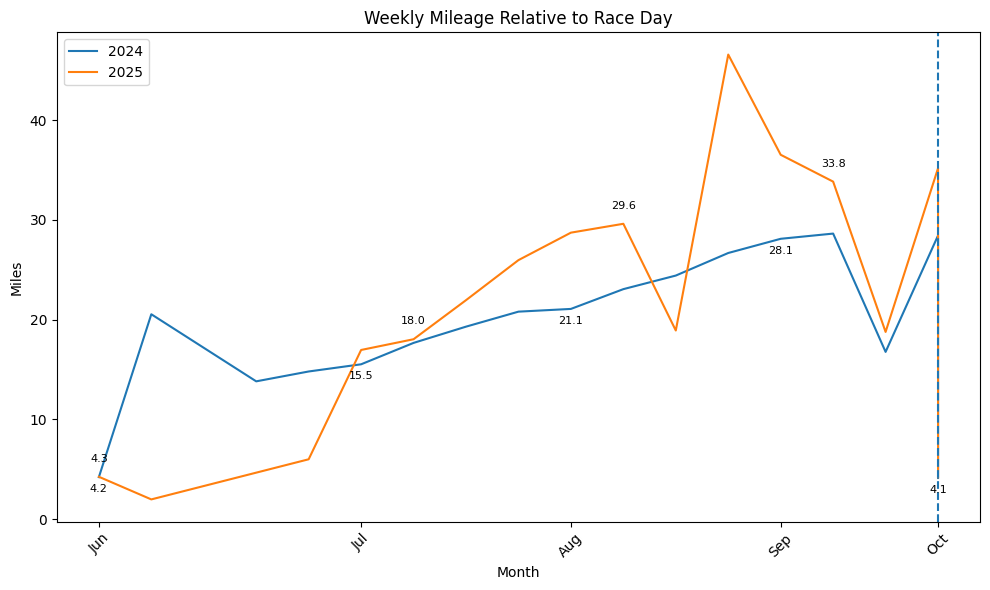

In [ ]:
# Add labels
plt.figure(figsize=(10, 6))

plt.plot(weekly24_trim['weeks_to_race'], weekly24_trim['DistanceInMiles'], label='2024')
plt.plot(weekly25_trim['weeks_to_race'], weekly25_trim['DistanceInMiles'], label='2025')

tick_positions = weekly24_trim['weeks_to_race'][::4]
tick_labels = weekly24_trim['newWeekStart'][::4].dt.strftime('%b')

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.axvline(0, linestyle='--')

# annotate 2024 points at tick positions
for _, row in weekly24_trim.iloc[::4].iterrows():
    plt.text(
        row['weeks_to_race'],
        row['DistanceInMiles'] - 1.5,
        f"{row['DistanceInMiles']:.1f}",
        ha='center',
        fontsize=8
    )

# annotate 2025 points at tick positions
for _, row in weekly25_trim.iloc[::4].iterrows():
    plt.text(
        row['weeks_to_race'],
        row['DistanceInMiles'] + 1.5,
        f"{row['DistanceInMiles']:.1f}",
        ha='center',
        fontsize=8
    )

plt.title('Weekly Mileage Relative to Race Day')
plt.xlabel('Month')
plt.ylabel('Miles')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
weekly_compare = weekly[
    (weekly['Activity Year'].isin([2024, 2025])) &
    (weekly['newWeekStart'].dt.month >= 7)
].copy()

weekly_compare[['Activity Year', 'newWeekStart', 'DistanceInMiles', 'Average Heart Rate']].head()

weekly_compare['Month'] = weekly_compare['newWeekStart'].dt.strftime('%b')
weekly_compare['Week Start'] = weekly_compare['newWeekStart'].dt.strftime('%Y-%m-%d')

weekly_table = weekly_compare[
    ['Activity Year', 'Month', 'Week Start', 'DistanceInMiles', 'Average Heart Rate']
].copy()

weekly_table.head(10)

,Activity Year,Month,Week Start,DistanceInMiles,Average Heart Rate
170,2024,Jul,2024-07-08,13.819291,146.666667
171,2024,Jul,2024-07-15,14.807271,136.000000
172,2024,Jul,2024-07-22,15.528061,139.666667
173,2024,Jul,2024-07-29,17.671791,142.333333
174,2024,Aug,2024-08-05,19.299783,136.500000
175,2024,Aug,2024-08-12,20.803501,142.333333
176,2024,Aug,2024-08-19,21.076904,144.333333
177,2024,Aug,2024-08-26,23.059078,147.000000
178,2024,Sep,2024-09-02,24.419880,137.666667
179,2024,Sep,2024-09-09,26.681671,141.333333


In [ ]:
weekly_compare['Month'] = weekly_compare['newWeekStart'].dt.strftime('%b')
weekly_compare['Week Start'] = weekly_compare['newWeekStart'].dt.strftime('%Y-%m-%d')

weekly_table = weekly_compare[
    ['Activity Year', 'Month', 'Week Start', 'DistanceInMiles', 'Average Heart Rate']
].copy()

weekly_table.head(10)

,Activity Year,Month,Week Start,DistanceInMiles,Average Heart Rate
170,2024,Jul,2024-07-08,13.819291,146.666667
171,2024,Jul,2024-07-15,14.807271,136.000000
172,2024,Jul,2024-07-22,15.528061,139.666667
173,2024,Jul,2024-07-29,17.671791,142.333333
174,2024,Aug,2024-08-05,19.299783,136.500000
175,2024,Aug,2024-08-12,20.803501,142.333333
176,2024,Aug,2024-08-19,21.076904,144.333333
177,2024,Aug,2024-08-26,23.059078,147.000000
178,2024,Sep,2024-09-02,24.419880,137.666667
179,2024,Sep,2024-09-09,26.681671,141.333333


In [ ]:
weekly_table['DistanceInMiles'] = weekly_table['DistanceInMiles'].round(1)
weekly_table['Average Heart Rate'] = weekly_table['Average Heart Rate'].round(1)

weekly_table.head(10)

,Activity Year,Month,Week Start,DistanceInMiles,Average Heart Rate
170,2024,Jul,2024-07-08,13.8,146.7
171,2024,Jul,2024-07-15,14.8,136.0
172,2024,Jul,2024-07-22,15.5,139.7
173,2024,Jul,2024-07-29,17.7,142.3
174,2024,Aug,2024-08-05,19.3,136.5
175,2024,Aug,2024-08-12,20.8,142.3
176,2024,Aug,2024-08-19,21.1,144.3
177,2024,Aug,2024-08-26,23.1,147.0
178,2024,Sep,2024-09-02,24.4,137.7
179,2024,Sep,2024-09-09,26.7,141.3


In [ ]:
#Lenth needs to be the same for each df
weekly_2024['Week'] = range(1, len(weekly_2024) + 1)
weekly_2025['Week'] = range(1, len(weekly_2025) + 1)

In [ ]:
weekly_side_by_side = pd.concat([
    weekly_2024[['Week', 'Month', 'DistanceInMiles', 'Average Heart Rate']].rename(columns={
        'Week': 'Week_2024',
        'Month': 'Month_2024',
        'DistanceInMiles': 'Mileage_2024',
        'Average Heart Rate': 'AvgHR_2024'
    }),
    weekly_2025[['Week', 'Month', 'DistanceInMiles', 'Average Heart Rate']].rename(columns={
        'Week': 'Week_2025',
        'Month': 'Month_2025',
        'DistanceInMiles': 'Mileage_2025',
        'Average Heart Rate': 'AvgHR_2025'
    })
], axis=1)

weekly_side_by_side = weekly_side_by_side.round({
    'Mileage_2024': 1,
    'Mileage_2025': 1,
    'AvgHR_2024': 1,
    'AvgHR_2025': 1
})

weekly_side_by_side.head(10)

,Week_2024,Month_2024,Mileage_2024,AvgHR_2024,Week_2025,Month_2025,Mileage_2025,AvgHR_2025
0,1,Jul,13.8,146.7,1.0,Jul,6.0,145.0
1,2,Jul,14.8,136.0,2.0,Jul,17.0,146.0
2,3,Jul,15.5,139.7,3.0,Jul,18.0,140.7
3,4,Jul,17.7,142.3,4.0,Jul,22.0,144.3
4,5,Aug,19.3,136.5,5.0,Aug,26.0,141.8
5,6,Aug,20.8,142.3,6.0,Aug,28.7,138.0
6,7,Aug,21.1,144.3,7.0,Aug,29.6,140.5
7,8,Aug,23.1,147.0,8.0,Aug,18.9,131.5
8,9,Sep,24.4,137.7,9.0,Sep,46.6,145.8
9,10,Sep,26.7,141.3,10.0,Sep,36.5,145.0


In [ ]:
weekly_2024 = weekly_compare[weekly_compare['Activity Year'] == 2024].copy()
weekly_2025 = weekly_compare[weekly_compare['Activity Year'] == 2025].copy()

weekly_2024['Month'] = weekly_2024['newWeekStart'].dt.strftime('%b')
weekly_2025['Month'] = weekly_2025['newWeekStart'].dt.strftime('%b')

weekly_2024 = weekly_2024.reset_index(drop=True)
weekly_2025 = weekly_2025.reset_index(drop=True)

weekly_side_by_side = pd.concat([
    weekly_2024[['Month', 'DistanceInMiles', 'Average Heart Rate']].rename(columns={
        'Month': 'Month_2024',
        'DistanceInMiles': 'Mileage_2024',
        'Average Heart Rate': 'AvgHR_2024'
    }),
    weekly_2025[['Month', 'DistanceInMiles', 'Average Heart Rate']].rename(columns={
        'Month': 'Month_2025',
        'DistanceInMiles': 'Mileage_2025',
        'Average Heart Rate': 'AvgHR_2025'
    })
], axis=1)

weekly_side_by_side['Mileage_2024'] = weekly_side_by_side['Mileage_2024'].round(1)
weekly_side_by_side['Mileage_2025'] = weekly_side_by_side['Mileage_2025'].round(1)
weekly_side_by_side['AvgHR_2024'] = weekly_side_by_side['AvgHR_2024'].round(1)
weekly_side_by_side['AvgHR_2025'] = weekly_side_by_side['AvgHR_2025'].round(1)

weekly_side_by_side.head(16)

,Month_2024,Mileage_2024,AvgHR_2024,Month_2025,Mileage_2025,AvgHR_2025
0,Jul,13.8,146.7,Jul,6.0,145.0
1,Jul,14.8,136.0,Jul,17.0,146.0
2,Jul,15.5,139.7,Jul,18.0,140.7
3,Jul,17.7,142.3,Jul,22.0,144.3
4,Aug,19.3,136.5,Aug,26.0,141.8
5,Aug,20.8,142.3,Aug,28.7,138.0
6,Aug,21.1,144.3,Aug,29.6,140.5
7,Aug,23.1,147.0,Aug,18.9,131.5
8,Sep,24.4,137.7,Sep,46.6,145.8
9,Sep,26.7,141.3,Sep,36.5,145.0


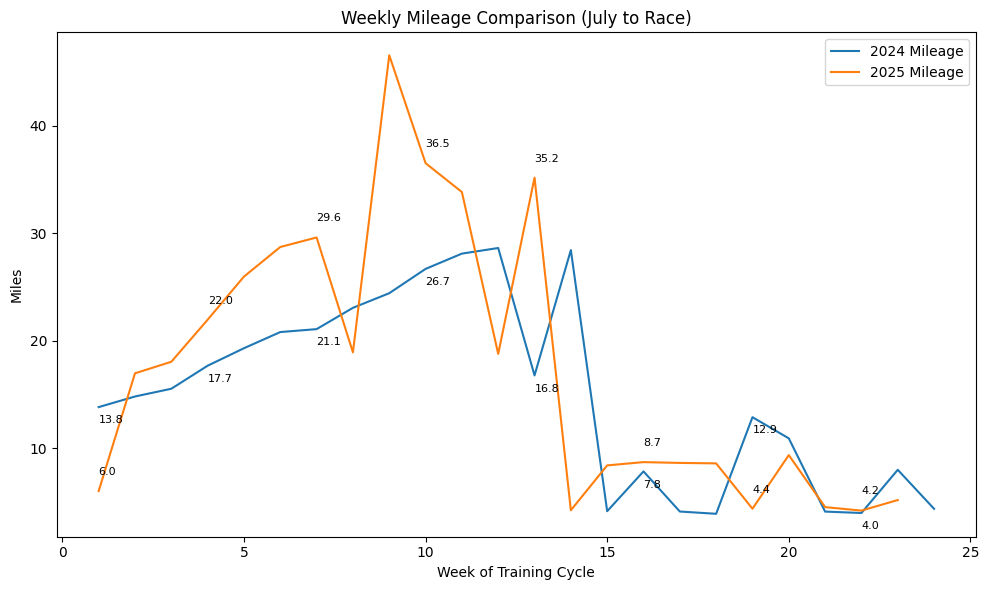

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(weekly_2024['Week'], weekly_2024['DistanceInMiles'], label='2024 Mileage')
plt.plot(weekly_2025['Week'], weekly_2025['DistanceInMiles'], label='2025 Mileage')

plt.title('Weekly Mileage Comparison (July to Race)')
plt.xlabel('Week of Training Cycle')
plt.ylabel('Miles')
plt.legend()

for _, row in weekly_2024.iloc[::3].iterrows():
    plt.text(row['Week'], row['DistanceInMiles'] - 1.5, f"{row['DistanceInMiles']:.1f}", fontsize=8)

for _, row in weekly_2025.iloc[::3].iterrows():
    plt.text(row['Week'], row['DistanceInMiles'] + 1.5, f"{row['DistanceInMiles']:.1f}", fontsize=8)

plt.tight_layout()
plt.show()